✅ Saved: arbeitsumfeld_stacked_anim_final.mp4


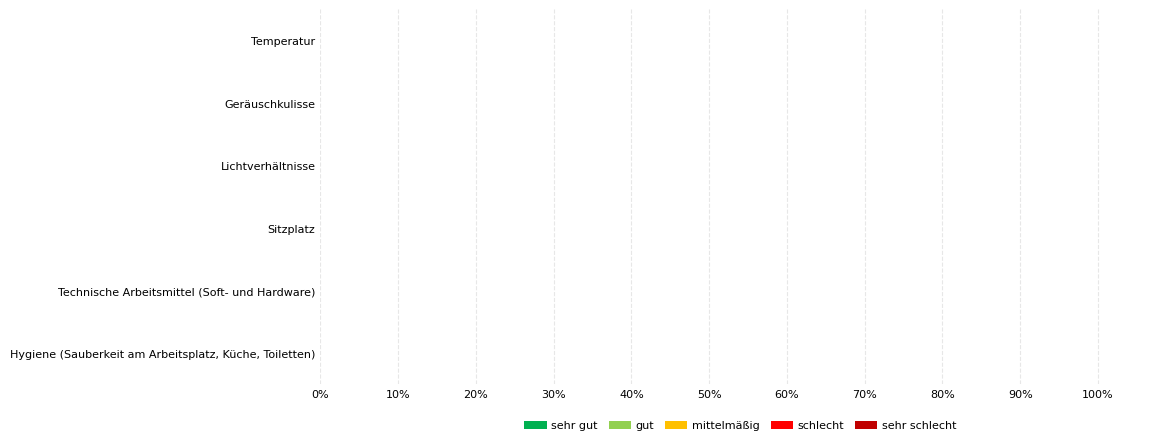

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML

# --- CONFIGURATION ---
fps = 30
total_duration_sec = 15
pause_duration_sec = 5
total_frames = int(fps * total_duration_sec)
pause_frames = int(fps * pause_duration_sec)
total_frames_with_pause = total_frames + pause_frames

# --- DATA ---
import numpy as np
import numpy as np

categories = [
    "Temperatur",
    "Geräuschkulisse",
    "Lichtverhältnisse",
    "Sitzplatz",
    "Technische Arbeitsmittel (Soft- und Hardware)",
    "Hygiene (Sauberkeit am Arbeitsplatz, Küche, Toiletten)"
]

# --- Data (in %) ---
# Columns: [sehr gut, gut, mittelmäßig, schlecht, sehr schlecht]
data = np.array([
    [11.8, 47.1, 11.8, 23.5, 5.9],   # Temperatur
    [5.9, 11.8, 29.4, 29.4, 23.5],   # Geräuschkulisse
    [35.3, 41.2, 17.6, 5.9, 0.0],    # Lichtverhältnisse
    [23.5, 52.9, 17.6, 0.0, 5.9],    # Sitzplatz
    [64.7, 23.5, 11.8, 0.0, 0.0],    # Technische Arbeitsmittel (Soft- und Hardware)
    [17.6, 64.7, 11.8, 5.9, 0.0]     # Hygiene (Sauberkeit am Arbeitsplatz, Küche, Toiletten)
])




colors = ["#00b050", "#92d050", "#ffc000", "#ff0000", "#c00000"]
labels = ["sehr gut", "gut", "mittelmäßig", "schlecht", "sehr schlecht"]


n_rows, n_cols = data.shape
proportions = data / 100  # normalize for timing

# --- FIGURE SETUP ---
fig, ax = plt.subplots(figsize=(12, 5))
plt.subplots_adjust(left=0.27, right=0.97, top=0.93, bottom=0.18)

ax.set_xlim(0, 108)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(categories, fontsize=15)
ax.invert_yaxis()

# X-axis formatting
ax.xaxis.tick_bottom()
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', which='major', length=0, labelsize=8)
ax.tick_params(axis='y', which='major', length=0, labelsize=8)

# Grid and spines
ax.grid(True, axis="x", linestyle="--", alpha=0.3)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for spine in ["right", "bottom", "left", "top"]:
    ax.spines[spine].set_visible(False)

# --- INITIALIZE bars ---
bars = []
for i in range(n_cols):
    bar = ax.barh(range(n_rows), np.zeros(n_rows),
                  color=colors[i], height=0.6, left=np.zeros(n_rows))
    bars.append(bar)

# --- ADD TEXT LABELS (start at left, move dynamically) ---
texts = [[
    ax.text(0, idx, "", color="white", va="center", ha="center",
            fontsize=8, weight="bold", alpha=1)
    for idx in range(n_rows)
] for _ in range(n_cols)]

# --- ANIMATION FUNCTION ---
def animate(frame):
    progress = min(frame / total_frames, 1)
    cum_left = np.zeros(n_rows)

    for i in range(n_rows):
        bar_progress = progress
        cum = 0
        for j in range(n_cols):
            seg_len = proportions[i, j]
            start = cum
            end = cum + seg_len
            cum = end

            if seg_len == 0:
                width = 0
            elif bar_progress <= start:
                width = 0
            elif bar_progress >= end:
                width = seg_len
            else:
                width = (bar_progress - start) / seg_len * seg_len

            # Update bar width and position
            bars[j][i].set_x(cum_left[i])
            bars[j][i].set_width(width * 100)

            # --- Update text dynamically: moves and counts up ---
            text_obj = texts[j][i]
            if width > 0.05:  # show only when visible
                text_x = bars[j][i].get_x() + (width * 100) / 2
                text_value = data[i, j] * (width / seg_len) if seg_len > 0 else 0
                text_obj.set_position((text_x, i))
                text_obj.set_text(f"{text_value:.1f}%")
                text_obj.set_alpha(1)
            else:
                text_obj.set_alpha(0)

            cum_left[i] += width * 100

    return [rect for group in bars for rect in group] + [txt for group in texts for txt in group]

# --- LEGEND ---
ax.legend(labels, loc="lower center", ncol=5,
          bbox_to_anchor=(0.5, -0.15), fontsize=8,
          frameon=False, handletextpad=0.4, columnspacing=1.0)

# --- CREATE ANIMATION ---
anim = FuncAnimation(fig, animate, frames=total_frames_with_pause,
                     interval=1000/fps, blit=False)

# --- DISPLAY INLINE ---
HTML(anim.to_html5_video())

# --- OPTIONAL: SAVE MP4 ---
writer = FFMpegWriter(fps=fps, codec="libx264", bitrate=2500, extra_args=["-pix_fmt", "yuv420p"])
anim.save("arbeitsumfeld_stacked_anim_final.mp4", writer=writer, dpi=300)
print("✅ Saved: arbeitsumfeld_stacked_anim_final.mp4")


In [2]:
from google.colab import files
files.download('arbeitsumfeld_stacked_anim_final.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# !ffmpeg -stream_loop 1 -i arbeitsumfeld_stacked_anim_final.mp4 -c copy arbeitsumfeld.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab